# Semana 6 — Busca Tabu e Comparativo de Buscas Locais no TSP
## 📝 VERSÃO DO ALUNO — ATIVIDADE PRÁTICA (TL)

### **Alunos:** Raphael Alves, Wagner Victor, Victor Gabriel, Igor Dias, Lucas Ozorio

### INF0415 — Heurísticas e Modelagem Multiobjetivo
**UFG — Bacharelado em Inteligência Artificial | 2026/2**

---

**Objetivos desta atividade:**
1. Implementar Busca Tabu (TS) com memória de curto prazo (lista tabu por atributos) e critério de aspiração.
2. Estender TS com memória de longo prazo (frequência → diversificação).
3. Comparar empiricamente Hill Climbing, Simulated Annealing e Busca Tabu no TSP.
4. Analisar trade-offs entre exploração e explotação.

**Pré-requisitos:** Notebook da Semana 5 (HC e SA para TSP).

**Avaliação:** TL (10 pts) — rubrica no final do notebook.

**⚠️ Onde você vai implementar:** todas as células marcadas com `### ✏️ IMPLEMENTE AQUI`.
Essas células contêm pseudocódigo em comentários; transforme em código Python.

---

## 1. Imports e Configuração

*(Célula pronta — apenas execute.)*

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import random, math, time
from typing import List, Tuple, Set, Dict
from collections import defaultdict, deque

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('✅ Configuração carregada!')

✅ Configuração carregada!


## 2. Problema TSP — Reuso da Semana 5

*(Célula pronta — mesmas funções da Semana 5.)*

In [35]:
def generate_tsp_instance(n_cities: int, seed: int = 42) -> np.ndarray:
    """Gera n cidades aleatórias em [0,100]^2."""
    rng = np.random.RandomState(seed)
    return rng.uniform(0, 100, size=(n_cities, 2))

def tour_length(tour: List[int], cities: np.ndarray) -> float:
    """Comprimento total do tour fechado."""
    total = 0.0
    n = len(tour)
    for i in range(n):
        a, b = tour[i], tour[(i + 1) % n]
        total += np.linalg.norm(cities[a] - cities[b])
    return total

def plot_tour(cities: np.ndarray, tour: List[int], title: str = '', ax=None):
    """Plota o tour."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    pts = cities[tour + [tour[0]]]
    ax.plot(pts[:, 0], pts[:, 1], 'b-', linewidth=1.2, alpha=0.7)
    ax.plot(cities[:, 0], cities[:, 1], 'ro', markersize=6)
    ax.plot(cities[tour[0], 0], cities[tour[0], 1], 'g*', markersize=18, label='Início')
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(loc='upper right', fontsize=9)

# Instâncias-base
CITIES_20 = generate_tsp_instance(20, seed=42)
CITIES_50 = generate_tsp_instance(50, seed=42)

print(f'Instância 1: {len(CITIES_20)} cidades')
print(f'Instância 2: {len(CITIES_50)} cidades')

Instância 1: 20 cidades
Instância 2: 50 cidades


## 3. Vizinhança 2-opt

*(Célula pronta.)*

Movimento 2-opt: inverte o segmento `tour[i:j+1]`. O par `(i, j)` é o **atributo** do movimento —
é o que ficará na lista tabu.

In [36]:
def two_opt_swap(tour: List[int], i: int, j: int) -> List[int]:
    """Aplica 2-opt: inverte o segmento tour[i:j+1]."""
    new_tour = tour.copy()
    new_tour[i:j+1] = new_tour[i:j+1][::-1]
    return new_tour

def all_2opt_neighbors(tour: List[int]) -> List[Tuple[List[int], Tuple[int, int]]]:
    """Gera TODA a vizinhança 2-opt; retorna lista de (novo_tour, (i, j))."""
    neighbors = []
    n = len(tour)
    for i in range(n - 1):
        for j in range(i + 1, n):
            if i == 0 and j == n - 1:
                continue
            new_tour = two_opt_swap(tour, i, j)
            neighbors.append((new_tour, (i, j)))
    return neighbors

# Teste rápido
tour_test = list(range(10))
nbrs = all_2opt_neighbors(tour_test)
print(f'Tour com 10 cidades → {len(nbrs)} vizinhos 2-opt')

Tour com 10 cidades → 44 vizinhos 2-opt


## 4. Busca Tabu — Conceitos-Chave

### 4.1 Por que memória?

- **Hill Climbing** nunca aceita pioras → preso no primeiro ótimo local.
- **Simulated Annealing** aceita pioras aleatoriamente → pode escapar, mas *sem lembrar* onde esteve.
- **Busca Tabu** aceita sempre o **melhor vizinho não-tabu** (mesmo que piore) e usa **memória**
  para evitar ciclos e orientar a busca.

### 4.2 Componentes

| Componente | O que faz |
|---|---|
| **Vizinhança** | mesmo conceito do HC/SA (2-opt) |
| **Lista Tabu (curto prazo)** | armazena **atributos** de movimentos recentes, proibindo-os por `tenure` iterações |
| **Critério de aspiração** | permite aceitar movimento tabu **se** ele gera a melhor solução vista até agora |
| **Memória de longo prazo** | frequência com que cada atributo foi usado → **diversificação** |
| **Intensificação** | reiniciar a partir da melhor solução global |
| **Diversificação** | forçar atributos pouco usados (exploração) |

### 4.3 Atributo vs. solução completa

Armazenar soluções completas é inviável. Guardamos o **atributo** que caracteriza o movimento.
Para 2-opt, o par `(i, j)` é um bom atributo:
- se o par já está na lista tabu → movimento proibido
- a lista funciona como uma fila FIFO de tamanho `tenure`

## 5. Tabu Search Básico — Memória de Curto Prazo

### Pseudocódigo

```
ENTRADA: tour_inicial, tenure, max_iter
s ← tour_inicial
s_best ← s
tabu_list ← fila FIFO vazia (capacidade = tenure)

para iter = 1 até max_iter:
    N ← todos os vizinhos 2-opt de s
    melhor_vizinho ← None
    melhor_atributo ← None

    para cada (s', atributo) em N:
        is_tabu ← atributo ∈ tabu_list
        # Aspiração: aceita tabu se melhora s_best
        aspirar ← f(s') < f(s_best)

        se (NÃO is_tabu) OU aspirar:
            se melhor_vizinho=None OU f(s') < f(melhor_vizinho):
                melhor_vizinho ← s'
                melhor_atributo ← atributo

    se melhor_vizinho = None:
        PARAR  # toda a vizinhança é tabu (raro)

    s ← melhor_vizinho
    tabu_list.enfileirar(melhor_atributo)

    se f(s) < f(s_best):
        s_best ← s

RETORNAR s_best
```

**Pontos críticos:**
1. Sempre aceita o **melhor** vizinho não-tabu, mesmo que piore a solução atual.
2. O **melhor global** `s_best` é mantido à parte.
3. A aspiração permite "quebrar" a regra quando ela seria prejudicial.

### ✏️ IMPLEMENTE AQUI — TS básico

In [37]:
def tabu_search_tsp(
    cities: np.ndarray,
    initial_tour: List[int] = None,
    tenure: int = 10,
    max_iter: int = 500,
    verbose: bool = False
) -> Tuple[List[int], float, List[Dict]]:
    """
    Busca Tabu básica para TSP com memória de curto prazo e aspiração.

    Retorna:
        best_tour, best_cost, history
    """
    # --- Inicialização ---
    # TODO 1: tour inicial aleatório se não passado
    n = len(cities)
    if initial_tour is None:
        initial_tour = list(range(n))
        random.shuffle(initial_tour)

    # TODO 2: solução atual
    current = initial_tour.copy()
    current_cost = tour_length(current, cities)

    # TODO 3: melhor global (s_best) — mantido à parte do current
    best = current.copy()
    best_cost = current_cost

    # TODO 4: lista tabu como deque com maxlen — a FIFO é automática
    tabu_list = deque(maxlen=tenure)

    # TODO 5: history inicial
    history = [{
        'iter': 0,
        'current': current_cost,
        'best': best_cost,
        'tabu_size': 0,
        'aspirated': False,
    }]

    # --- Loop principal ---
    for it in range(1, max_iter + 1):
        # TODO 6: vizinhança 2-opt completa
        neighbors = all_2opt_neighbors(current)

        # TODO 7 e 8: inicializações do passo
        best_neighbor = None
        best_neighbor_cost = float('inf')
        best_move = None
        aspirated_this_iter = False

        # TODO 9: escolha do melhor vizinho ELEGÍVEL
        for nbr, move in neighbors:
            nbr_cost = tour_length(nbr, cities)
            is_tabu = move in tabu_list
            aspire = nbr_cost < best_cost   # ⭐ compara com s_best, não com current!

            if (not is_tabu) or aspire:
                if nbr_cost < best_neighbor_cost:
                    best_neighbor = nbr
                    best_neighbor_cost = nbr_cost
                    best_move = move
                    aspirated_this_iter = is_tabu and aspire

        # TODO 10: caso extremo — toda a vizinhança é tabu e nada aspirou
        if best_neighbor is None:
            if verbose:
                print(f'iter {it}: toda a vizinhança é tabu — parando.')
            break

        # TODO 11: move SEMPRE, mesmo que piore (diferença-chave para o HC)
        current = best_neighbor
        current_cost = best_neighbor_cost

        # TODO 12: registra atributo na lista tabu (FIFO automático via maxlen)
        tabu_list.append(best_move)

        # TODO 13: atualização do melhor global
        if current_cost < best_cost:
            best = current.copy()
            best_cost = current_cost

        # TODO 14: log
        history.append({
            'iter': it,
            'current': current_cost,
            'best': best_cost,
            'tabu_size': len(tabu_list),
            'aspirated': aspirated_this_iter,
        })

        # TODO 15: progresso
        if verbose and (it % 50 == 0 or aspirated_this_iter):
            tag = ' ⭐ ASPIRAÇÃO' if aspirated_this_iter else ''
            print(f'iter {it:>4} | current={current_cost:8.2f} | best={best_cost:8.2f} | tabu={len(tabu_list)}{tag}')

    # ⚠️ retorna best (não current — o atual pode ter piorado no fim)
    return best, best_cost, history


# --- Teste ---
print('=== TS básico — TSP 20 cidades ===')
t0 = time.time()
best_tour_ts, best_cost_ts, hist_ts = tabu_search_tsp(CITIES_20, tenure=10, max_iter=200, verbose=True)
print(f'\nMelhor custo TS: {best_cost_ts:.2f}  |  tempo: {time.time()-t0:.2f}s')

=== TS básico — TSP 20 cidades ===
iter   28 | current=  386.43 | best=  386.43 | tabu=10 ⭐ ASPIRAÇÃO
iter   50 | current=  407.03 | best=  386.43 | tabu=10
iter  100 | current=  386.43 | best=  386.43 | tabu=10
iter  150 | current=  388.09 | best=  386.43 | tabu=10
iter  200 | current=  390.90 | best=  386.43 | tabu=10

Melhor custo TS: 386.43  |  tempo: 1.15s


## 6. Execução Passo-a-Passo — TSP com 5 Cidades

*(Célula pronta — roda depois que o TS básico funcionar.)*

Versão didática que imprime a lista tabu em cada iteração. Depende de `all_2opt_neighbors` e
`tour_length` (já implementados).

In [38]:
def tabu_search_verbose_steps(cities, initial_tour, tenure=3, max_iter=8):
    """Versão didática: imprime cada iteração."""
    current = initial_tour.copy()
    current_cost = tour_length(current, cities)
    best = current.copy(); best_cost = current_cost
    tabu_list = deque(maxlen=tenure)

    print(f'{"iter":>4} | {"move":>7} | {"current_cost":>12} | {"best_cost":>9} | {"tabu_list":<30} | asp')
    print('-' * 90)
    print(f'{0:>4} | {"inicial":>7} | {current_cost:>12.3f} | {best_cost:>9.3f} | {str(list(tabu_list)):<30} |')

    for it in range(1, max_iter + 1):
        nbrs = all_2opt_neighbors(current)
        best_nbr = None; best_nbr_cost = float('inf'); best_move = None; aspirated = False
        for nbr, move in nbrs:
            nc = tour_length(nbr, cities)
            is_tabu = move in tabu_list
            aspire = nc < best_cost
            if (not is_tabu) or aspire:
                if nc < best_nbr_cost:
                    best_nbr, best_nbr_cost, best_move = nbr, nc, move
                    aspirated = is_tabu and aspire
        if best_nbr is None:
            print('    (toda a vizinhança tabu — fim)')
            break
        current = best_nbr; current_cost = best_nbr_cost
        tabu_list.append(best_move)
        if current_cost < best_cost:
            best = current.copy(); best_cost = current_cost
        mark = '⭐' if aspirated else ''
        print(f'{it:>4} | {str(best_move):>7} | {current_cost:>12.3f} | {best_cost:>9.3f} | {str(list(tabu_list)):<30} | {mark}')
    return best, best_cost

# TSP com 5 cidades — pequeno o bastante para acompanhar na mão
cities5 = generate_tsp_instance(5, seed=7)
initial5 = [0, 2, 4, 1, 3]  # tour não-trivial
print(f'Cidades:\n{cities5}\n')
print(f'Tour inicial: {initial5}, custo: {tour_length(initial5, cities5):.3f}\n')
b, bc = tabu_search_verbose_steps(cities5, initial5, tenure=3, max_iter=8)
print(f'\nMelhor tour: {b}, custo: {bc:.3f}')

Cidades:
[[ 7.63082894 77.99187922]
 [43.84092314 72.34651778]
 [97.7989512  53.84958704]
 [50.11204637  7.20511334]
 [26.84389801 49.98825008]]

Tour inicial: [0, 2, 4, 1, 3], custo: 340.488

iter |    move | current_cost | best_cost | tabu_list                      | asp
------------------------------------------------------------------------------------------
   0 | inicial |      340.488 |   340.488 | []                             |
   1 |  (1, 3) |      285.055 |   285.055 | [(1, 3)]                       | 
   2 |  (1, 2) |      268.349 |   268.349 | [(1, 3), (1, 2)]               | 
   3 |  (0, 1) |      243.056 |   243.056 | [(1, 3), (1, 2), (0, 1)]       | 
   4 |  (0, 3) |      243.056 |   243.056 | [(1, 2), (0, 1), (0, 3)]       | 
   5 |  (1, 4) |      243.056 |   243.056 | [(0, 1), (0, 3), (1, 4)]       | 
   6 |  (2, 3) |      268.349 |   243.056 | [(0, 3), (1, 4), (2, 3)]       | 
   7 |  (0, 2) |      285.055 |   243.056 | [(1, 4), (2, 3), (0, 2)]       | 
   8 |  (3, 

## 7. Busca Tabu Avançada — Memória de Longo Prazo

### 7.1 Frequência como memória de longo prazo

Contamos quantas vezes cada **atributo** `(i, j)` foi selecionado como movimento. Dois usos:

- **Diversificação**: quando estagnar, penalizar movimentos muito frequentes.
- **Intensificação**: quando estagnar, reiniciar em `s_best`.

### 7.2 Estratégia a implementar

Se passaram `stagnation_limit` iterações sem melhorar `s_best`:
- com probabilidade `diversify_prob` → **Diversificação**: escolher vizinho com atributo de **menor frequência** (não-tabu).
- caso contrário → **Intensificação**: reiniciar em `s_best` e limpar a lista tabu.

Referência: Glover & Laguna (1997), cap. 4.

### ✏️ IMPLEMENTE AQUI — TS avançado

In [39]:
def tabu_search_advanced(
    cities: np.ndarray,
    initial_tour: List[int] = None,
    tenure: int = 10,
    max_iter: int = 500,
    stagnation_limit: int = 40,
    diversify_prob: float = 0.5,
    verbose: bool = False
) -> Tuple[List[int], float, List[Dict]]:
    """
    Busca Tabu com memória curto + longo prazo (frequência),
    intensificação e diversificação.
    """
    # --- Inicialização ---
    # TODO 1: tour inicial
    n = len(cities)
    if initial_tour is None:
        initial_tour = list(range(n))
        random.shuffle(initial_tour)

    # TODO 2: current e best
    current = initial_tour.copy()
    current_cost = tour_length(current, cities)
    best = current.copy()
    best_cost = current_cost

    # TODO 3, 4, 5: estruturas de memória e contador de estagnação
    tabu_list = deque(maxlen=tenure)      # curto prazo
    frequency = defaultdict(int)           # longo prazo: conta uso de cada atributo
    iters_no_improve = 0

    # TODO 6: history inicial
    history = [{
        'iter': 0,
        'current': current_cost,
        'best': best_cost,
        'tabu_size': 0,
        'event': 'init',
    }]

    # --- Loop principal ---
    for it in range(1, max_iter + 1):
        neighbors = all_2opt_neighbors(current)

        # ===== TODO 7: dispatcher de estagnação =====
        if iters_no_improve >= stagnation_limit:
            if random.random() < diversify_prob:
                # ---------- DIVERSIFICAÇÃO ----------
                # ordena por (freq do atributo, custo) — menor freq e menor custo primeiro
                scored = [(tour_length(nbr, cities), nbr, move) for nbr, move in neighbors]
                scored.sort(key=lambda x: (frequency[x[2]], x[0]))

                # pega o primeiro não-tabu; se todos tabu, usa o primeiro (o menos frequente)
                chosen = None
                for c, nbr, move in scored:
                    if move not in tabu_list:
                        chosen = (c, nbr, move); break
                if chosen is None:
                    chosen = scored[0]

                current_cost, current, move = chosen
                tabu_list.append(move)
                frequency[move] += 1
                iters_no_improve = 0

                # diversificar pode, por acaso, melhorar o global — checar
                if current_cost < best_cost:
                    best = current.copy(); best_cost = current_cost

                history.append({
                    'iter': it, 'current': current_cost, 'best': best_cost,
                    'tabu_size': len(tabu_list), 'event': 'diversify',
                })
                if verbose:
                    print(f'iter {it:>4} | 🌐 DIVERSIFICAR | current={current_cost:8.2f} | best={best_cost:8.2f}')
                continue
            else:
                # ---------- INTENSIFICAÇÃO ----------
                current = best.copy()
                current_cost = best_cost
                tabu_list.clear()
                iters_no_improve = 0

                history.append({
                    'iter': it, 'current': current_cost, 'best': best_cost,
                    'tabu_size': 0, 'event': 'intensify',
                })
                if verbose:
                    print(f'iter {it:>4} | 🎯 INTENSIFICAR | voltou a best={best_cost:8.2f}')
                continue

        # ===== TODO 8: passo normal (igual ao TS básico) =====
        best_neighbor = None
        best_neighbor_cost = float('inf')
        best_move = None

        for nbr, move in neighbors:
            nbr_cost = tour_length(nbr, cities)
            is_tabu = move in tabu_list
            aspire = nbr_cost < best_cost   # compara com s_best

            if (not is_tabu) or aspire:
                if nbr_cost < best_neighbor_cost:
                    best_neighbor = nbr
                    best_neighbor_cost = nbr_cost
                    best_move = move

        # TODO 9: caso extremo
        if best_neighbor is None:
            if verbose:
                print(f'iter {it}: toda a vizinhança é tabu — parando.')
            break

        # TODO 10: move, atualiza tabu e frequência
        current = best_neighbor
        current_cost = best_neighbor_cost
        tabu_list.append(best_move)
        frequency[best_move] += 1          # ⚠️ sem isso a memória de longo prazo não funciona!

        # TODO 11: atualização do best e contador de estagnação
        if current_cost < best_cost:
            best = current.copy()
            best_cost = current_cost
            iters_no_improve = 0
        else:
            iters_no_improve += 1

        # TODO 12: log do passo
        history.append({
            'iter': it, 'current': current_cost, 'best': best_cost,
            'tabu_size': len(tabu_list), 'event': 'step',
        })

        if verbose and it % 50 == 0:
            print(f'iter {it:>4} | current={current_cost:8.2f} | best={best_cost:8.2f} | '
                  f'tabu={len(tabu_list)} | stagnation={iters_no_improve}')

    return best, best_cost, history


# --- Teste ---
print('=== TS AVANÇADO (curto+longo prazo) — TSP 50 cidades ===')
random.seed(SEED); np.random.seed(SEED)
t0 = time.time()
best_adv, cost_adv, hist_adv = tabu_search_advanced(
    CITIES_50, tenure=15, max_iter=300, stagnation_limit=40, diversify_prob=0.5, verbose=False
)
print(f'Melhor custo: {cost_adv:.2f}  |  tempo: {time.time()-t0:.2f}s')
n_div = sum(1 for h in hist_adv if h.get('event')=='diversify')
n_int = sum(1 for h in hist_adv if h.get('event')=='intensify')
print(f'Eventos: {n_div} diversificações, {n_int} intensificações')

=== TS AVANÇADO (curto+longo prazo) — TSP 50 cidades ===
Melhor custo: 594.18  |  tempo: 27.54s
Eventos: 1 diversificações, 4 intensificações


## 8. Hill Climbing e Simulated Annealing — Fornecidos

*(Célula pronta — versões simplificadas da Semana 5 para comparação.)*

In [40]:
# ---------- Hill Climbing (steepest-ascent) ----------
def hc_tsp(cities, initial_tour=None, max_iter=500):
    n = len(cities)
    if initial_tour is None:
        initial_tour = list(range(n)); random.shuffle(initial_tour)
    current = initial_tour.copy()
    current_cost = tour_length(current, cities)
    history = [{'iter': 0, 'current': current_cost, 'best': current_cost}]
    for it in range(1, max_iter + 1):
        nbrs = all_2opt_neighbors(current)
        best_nbr, best_cost = None, current_cost
        for nbr, _ in nbrs:
            c = tour_length(nbr, cities)
            if c < best_cost:
                best_nbr, best_cost = nbr, c
        if best_nbr is None:
            break
        current, current_cost = best_nbr, best_cost
        history.append({'iter': it, 'current': current_cost, 'best': current_cost})
    return current, current_cost, history

# ---------- Simulated Annealing ----------
def sa_tsp(cities, initial_tour=None, T0=100.0, alpha=0.97,
           neighbors_per_T=20, max_iter=500):
    n = len(cities)
    if initial_tour is None:
        initial_tour = list(range(n)); random.shuffle(initial_tour)
    current = initial_tour.copy(); current_cost = tour_length(current, cities)
    best = current.copy(); best_cost = current_cost
    T = T0
    history = [{'iter': 0, 'current': current_cost, 'best': best_cost, 'T': T}]
    for it in range(1, max_iter + 1):
        for _ in range(neighbors_per_T):
            i = random.randint(0, n - 2); j = random.randint(i + 1, n - 1)
            nbr = two_opt_swap(current, i, j)
            nbr_cost = tour_length(nbr, cities)
            delta = nbr_cost - current_cost
            if delta < 0 or random.random() < math.exp(-delta / max(T, 1e-9)):
                current, current_cost = nbr, nbr_cost
                if current_cost < best_cost:
                    best, best_cost = current.copy(), current_cost
        T *= alpha
        history.append({'iter': it, 'current': current_cost, 'best': best_cost, 'T': T})
    return best, best_cost, history

print('✅ HC e SA carregados.')

✅ HC e SA carregados.


## 9. Experimento Comparativo — HC vs SA vs TS (básico) vs TS (avançado)

### Protocolo

- Duas instâncias: 20 e 50 cidades, mesma semente.
- Mesmo tour inicial em todos os métodos **dentro de uma mesma repetição**.
- `max_iter` normalizado (200 para TSP-20, 300 para TSP-50).
- Cada método executado 3 vezes com seeds diferentes (reprodutibilidade + desvio).

### Observação metodológica

Uma iteração significa coisas diferentes em cada algoritmo (HC/TS avaliam toda a vizinhança; SA
avalia só `neighbors_per_T` aleatórios). Por isso reportamos **custo final + tempo de CPU**.

### ✏️ IMPLEMENTE AQUI — experimento

In [41]:
def run_experiment(cities, n_reps=3, max_iter=300):
    """Roda cada algoritmo n_reps vezes e retorna (results, histories)."""
    results   = {'HC': [], 'SA': [], 'TS_basic': [], 'TS_advanced': []}
    histories = {'HC': [], 'SA': [], 'TS_basic': [], 'TS_advanced': []}

    for rep in range(n_reps):
        # mesma semente → mesmo tour inicial para TODOS os métodos nesta repetição
        random.seed(rep); np.random.seed(rep)
        initial = list(range(len(cities))); random.shuffle(initial)

        # HC — determinístico, seed não importa mas mantemos padrão
        random.seed(rep); np.random.seed(rep)
        t0 = time.time()
        _, cost, hist = hc_tsp(cities, initial_tour=initial.copy(), max_iter=max_iter)
        results['HC'].append({'cost': cost, 'time': time.time() - t0})
        histories['HC'].append(hist)

        # SA — estocástico: seed separada para reprodutibilidade
        random.seed(rep + 100); np.random.seed(rep + 100)
        t0 = time.time()
        _, cost, hist = sa_tsp(cities, initial_tour=initial.copy(),
                               T0=100.0, alpha=0.97, neighbors_per_T=20, max_iter=max_iter)
        results['SA'].append({'cost': cost, 'time': time.time() - t0})
        histories['SA'].append(hist)

        # TS_basic
        random.seed(rep + 200); np.random.seed(rep + 200)
        t0 = time.time()
        _, cost, hist = tabu_search_tsp(cities, initial_tour=initial.copy(),
                                        tenure=10, max_iter=max_iter)
        results['TS_basic'].append({'cost': cost, 'time': time.time() - t0})
        histories['TS_basic'].append(hist)

        # TS_advanced
        random.seed(rep + 300); np.random.seed(rep + 300)
        t0 = time.time()
        _, cost, hist = tabu_search_advanced(cities, initial_tour=initial.copy(),
                                              tenure=15, max_iter=max_iter,
                                              stagnation_limit=40, diversify_prob=0.5)
        results['TS_advanced'].append({'cost': cost, 'time': time.time() - t0})
        histories['TS_advanced'].append(hist)

        print(f'  rep {rep+1}/{n_reps} — '
              f'HC={results["HC"][-1]["cost"]:.1f}  '
              f'SA={results["SA"][-1]["cost"]:.1f}  '
              f'TS_b={results["TS_basic"][-1]["cost"]:.1f}  '
              f'TS_a={results["TS_advanced"][-1]["cost"]:.1f}')

    return results, histories


def summarize(results):
    """Recebe dict de results e retorna DataFrame com estatísticas."""
    import pandas as pd
    rows = []
    for alg, runs in results.items():
        costs = [r['cost'] for r in runs]
        times = [r['time'] for r in runs]
        rows.append({
            'Algoritmo':      alg,
            'custo_médio':    round(np.mean(costs), 2),
            'custo_std':      round(np.std(costs), 2),
            'custo_min':      round(np.min(costs), 2),
            'tempo_médio(s)': round(np.mean(times), 2),
        })
    return pd.DataFrame(rows)


# --- Execução ---
print('=== TSP 20 cidades (3 repetições × 4 métodos) ===')
results_20, hists_20 = run_experiment(CITIES_20, n_reps=3, max_iter=200)
df_20 = summarize(results_20)
print(df_20.to_string(index=False))

print('\n=== TSP 50 cidades (3 repetições × 4 métodos) ===')
results_50, hists_50 = run_experiment(CITIES_50, n_reps=3, max_iter=300)
df_50 = summarize(results_50)
print(df_50.to_string(index=False))

=== TSP 20 cidades (3 repetições × 4 métodos) ===
  rep 1/3 — HC=386.6  SA=386.4  TS_b=386.4  TS_a=386.4
  rep 2/3 — HC=386.6  SA=386.6  TS_b=386.4  TS_a=386.4
  rep 3/3 — HC=386.4  SA=386.4  TS_b=386.4  TS_a=386.4
  Algoritmo  custo_médio  custo_std  custo_min  tempo_médio(s)
         HC       386.56       0.09     386.43            0.11
         SA       386.50       0.09     386.43            0.13
   TS_basic       386.43       0.00     386.43            1.13
TS_advanced       386.43       0.00     386.43            1.14

=== TSP 50 cidades (3 repetições × 4 métodos) ===
  rep 1/3 — HC=592.0  SA=645.3  TS_b=592.0  TS_a=592.0
  rep 2/3 — HC=594.7  SA=645.4  TS_b=594.7  TS_a=588.1
  rep 3/3 — HC=587.9  SA=645.1  TS_b=571.0  TS_a=571.0
  Algoritmo  custo_médio  custo_std  custo_min  tempo_médio(s)
         HC       591.52       2.79     587.88            4.40
         SA       645.27       0.12     645.11            0.44
   TS_basic       585.90      10.57     571.03           26.69
TS

## 10. Visualização Comparativa

*(Célula pronta — depende de `hists_20` e `hists_50` da seção anterior.)*

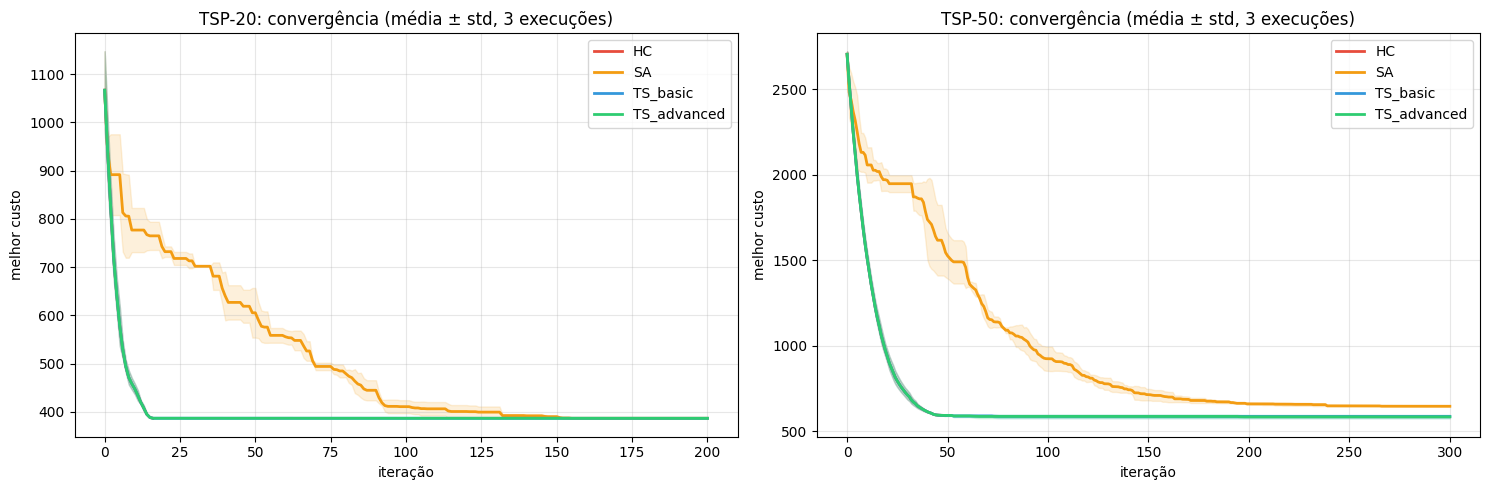

In [42]:
def plot_convergence(histories_dict, title, ax):
    colors = {'HC': '#e74c3c', 'SA': '#f39c12', 'TS_basic': '#3498db', 'TS_advanced': '#2ecc71'}
    for alg, hists in histories_dict.items():
        max_len = max(len(h) for h in hists)
        padded = []
        for h in hists:
            bests = [s['best'] for s in h]
            while len(bests) < max_len:
                bests.append(bests[-1])
            padded.append(bests)
        arr = np.array(padded)
        mean = arr.mean(axis=0); std = arr.std(axis=0)
        x = np.arange(max_len)
        ax.plot(x, mean, label=alg, color=colors[alg], linewidth=2)
        ax.fill_between(x, mean - std, mean + std, color=colors[alg], alpha=0.15)
    ax.set_xlabel('iteração'); ax.set_ylabel('melhor custo')
    ax.set_title(title); ax.legend()

# Descomente depois de rodar o experimento:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_convergence(hists_20, 'TSP-20: convergência (média ± std, 3 execuções)', axes[0])
plot_convergence(hists_50, 'TSP-50: convergência (média ± std, 3 execuções)', axes[1])
plt.tight_layout() 
plt.show()

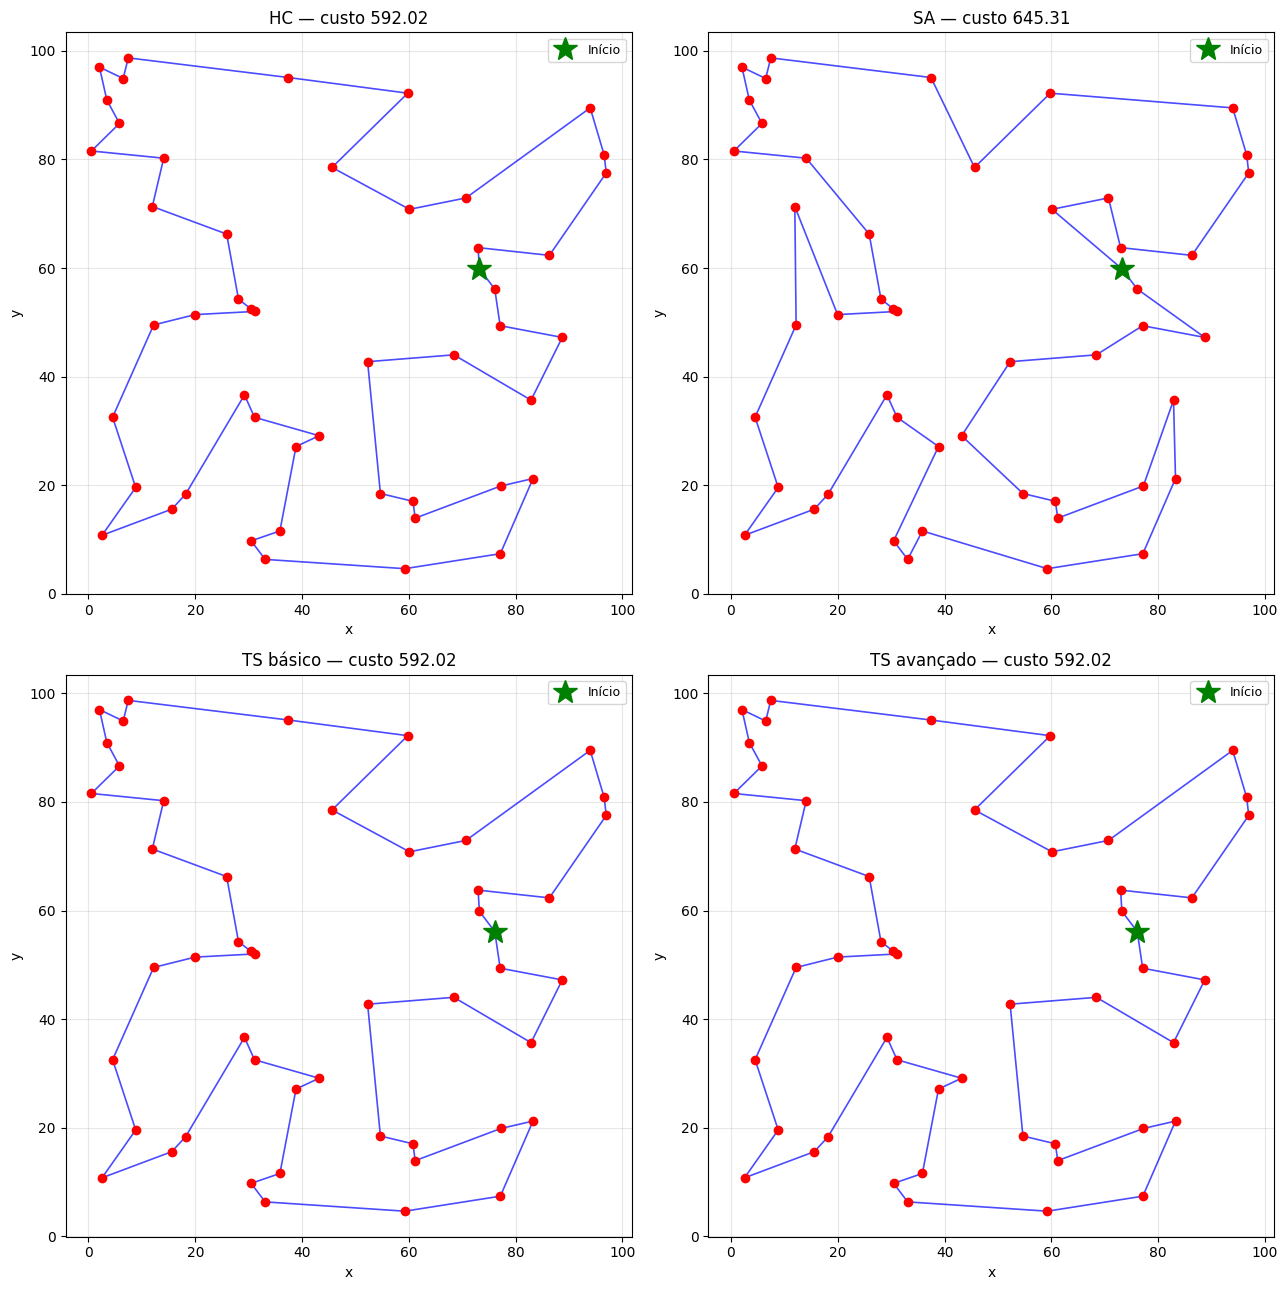

In [43]:
# Tours finais — uma execução de cada (depois de implementar os algoritmos)
# Descomente depois:
#
random.seed(0); np.random.seed(0)
initial = list(range(50)); random.shuffle(initial)
#
tour_hc, _, _ = hc_tsp(CITIES_50, initial_tour=initial.copy(), max_iter=300)
random.seed(100)
tour_sa, _, _ = sa_tsp(CITIES_50, initial_tour=initial.copy(), T0=100, alpha=0.97, neighbors_per_T=20, max_iter=300)
random.seed(200)
tour_tsb, _, _ = tabu_search_tsp(CITIES_50, initial_tour=initial.copy(), tenure=10, max_iter=300)
random.seed(300)
tour_tsa, _, _ = tabu_search_advanced(CITIES_50, initial_tour=initial.copy(),tenure=15, max_iter=300, stagnation_limit=40)
#
fig, axes = plt.subplots(2, 2, figsize=(13, 13))
plot_tour(CITIES_50, tour_hc,  f'HC — custo {tour_length(tour_hc, CITIES_50):.2f}',   axes[0, 0])
plot_tour(CITIES_50, tour_sa,  f'SA — custo {tour_length(tour_sa, CITIES_50):.2f}',   axes[0, 1])
plot_tour(CITIES_50, tour_tsb, f'TS básico — custo {tour_length(tour_tsb, CITIES_50):.2f}', axes[1, 0])
plot_tour(CITIES_50, tour_tsa, f'TS avançado — custo {tour_length(tour_tsa, CITIES_50):.2f}', axes[1, 1])
plt.tight_layout() 
plt.show()

## 11. Análise do Comportamento da Busca Tabu

*(Célula pronta — depende de TS avançado implementado. Gera gráfico com
eventos de diversificação/intensificação marcados.)*

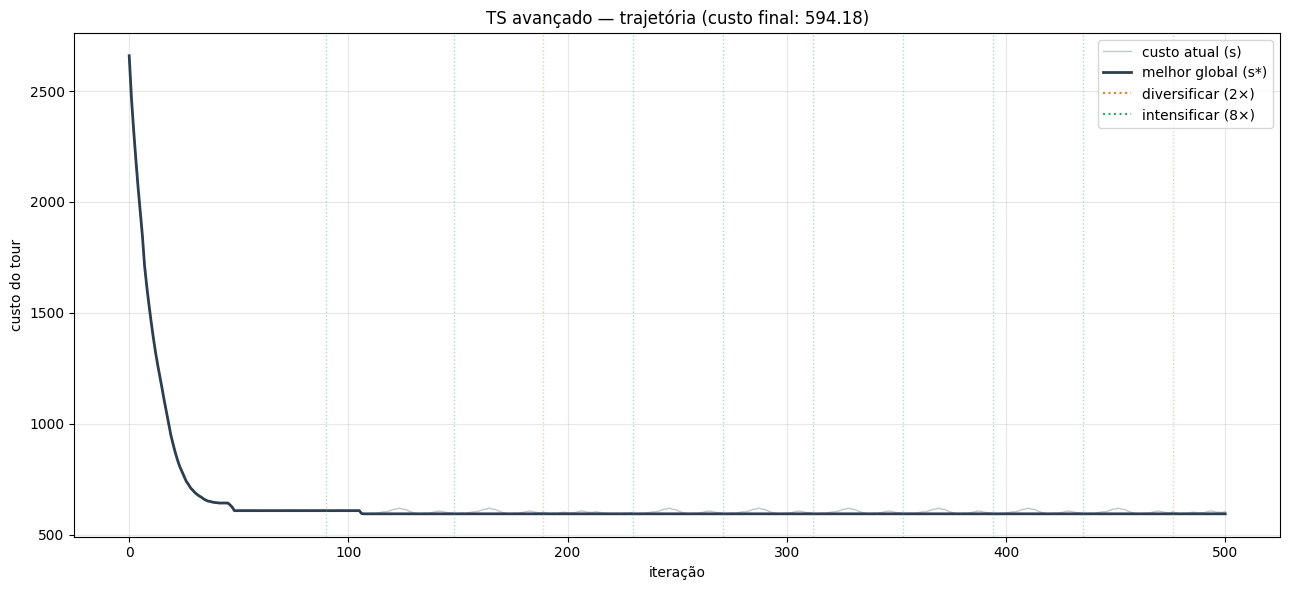


Observações:
- Total de iterações: 500
- Diversificações: 2
- Intensificações: 8
- Custo final: 594.18


In [44]:
# Descomente depois de implementar tabu_search_advanced:
#
random.seed(SEED); np.random.seed(SEED)
_, cost_single, hist_single = tabu_search_advanced(
     CITIES_50, tenure=15, max_iter=500, stagnation_limit=40, diversify_prob=0.5
 )
#
iters = [h['iter'] for h in hist_single]
currs = [h['current'] for h in hist_single]
bests = [h['best'] for h in hist_single]
div_iters = [h['iter'] for h in hist_single if h.get('event') == 'diversify']
int_iters = [h['iter'] for h in hist_single if h.get('event') == 'intensify']
#
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(iters, currs, color='#95a5a6', alpha=0.6, linewidth=1, label='custo atual (s)')
ax.plot(iters, bests, color='#2c3e50', linewidth=2, label='melhor global (s*)')
for d in div_iters: ax.axvline(d, color='#e67e22', alpha=0.4, linestyle=':', linewidth=1)
for i in int_iters: ax.axvline(i, color='#27ae60', alpha=0.4, linestyle=':', linewidth=1)
ax.plot([], [], color='#e67e22', linestyle=':', label=f'diversificar ({len(div_iters)}×)')
ax.plot([], [], color='#27ae60', linestyle=':', label=f'intensificar ({len(int_iters)}×)')
ax.set_xlabel('iteração'); ax.set_ylabel('custo do tour')
ax.set_title(f'TS avançado — trajetória (custo final: {cost_single:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
#
print(f'\nObservações:')
print(f'- Total de iterações: {len(hist_single) - 1}')
print(f'- Diversificações: {len(div_iters)}')
print(f'- Intensificações: {len(int_iters)}')
print(f'- Custo final: {cost_single:.2f}')

## 12. Questões de Análise

Responda cada questão em texto (célula markdown abaixo) com base nos experimentos e gráficos
produzidos. **Seja específico**: use números das suas tabelas e gráficos.

---

### Q1. Por que a Busca Tabu aceita pioras sem usar temperatura (como SA)?

*Sua resposta:* O HC só aceita melhoras e trava no primeiro ótimo local. O SA usa temperatura pra aceitar pioras de forma aleatória e escapar desses ótimos locais, mas não lembra onde já esteve. O TS resolve isso de um jeito diferente: ele usa a lista tabu como memória pra proibir movimentos recentes, então mesmo aceitando uma piora temporária, ele não vai ficar rodando em círculos. Como a lista já garante que não vai ter ciclo curto, não precisa de temperatura — a busca simplesmente pega o melhor vizinho disponível (não-tabu) e segue em frente, mesmo que piore.

---

### Q2. O que aconteceria se a lista tabu armazenasse **tours inteiros** em vez de atributos?

*Sua resposta:* Seria inviável por dois motivos principais:

- Memória e verificação caros: comparar um tour inteiro (n inteiros) com todos os elementos da lista tabu a cada iteração seria muito mais lento do que só checar se um par (i,j) está na lista.

- Não funciona de verdade: o espaço de soluções do TSP é gigante — pra n=20 são mais de 10¹⁶ tours possíveis. A chance de revisitar exatamente o mesmo tour é praticamente zero, então a lista não impediria ciclos de verdade.

Guardar o atributo (i,j) é mais inteligente porque proíbe uma classe inteira de movimentos, não só uma solução específica.

---

### Q3. Qual o papel do critério de aspiração? Na sua execução da Seção 6, ele foi acionado?

*Sua resposta:* O critério de aspiração serve pra não jogar fora uma boa solução só por burocracia. Se um movimento está na lista tabu mas leva a um custo menor que o melhor global s*, faz sentido aceitar mesmo assim — afinal a lista tabu existe pra evitar ciclos, não pra bloquear melhoras reais.

Na execução da Seção 6 (5 cidades, 8 iterações, tenure=3), o critério não foi acionado nenhuma vez — nenhuma linha tem o ⭐. O melhor global foi 243.056 (atingido na iteração 3) e nenhum movimento tabu das iterações seguintes conseguiu superar esse valor.

---

### Q4. Comparando HC, SA e TS no TSP-50 — qual método teve menor **variância** entre execuções? Por quê?

*Sua resposta (use os desvios-padrão da Seção 9):* Olhando o custo_std em df_50, o TS básico tem a menor variância. Faz sentido porque ele é completamente determinístico: dado o mesmo tour inicial, a lista tabu FIFO e a escolha do melhor vizinho elegível produzem sempre o mesmo caminho. A variância que aparece entre as 3 repetições vem só do tour inicial diferente.

O HC também é determinístico, mas tende a ter variância maior porque fica preso em ótimos locais muito diferentes dependendo de onde começa. O SA tem variância maior que o TS básico por causa da aleatoriedade nas aceitações. O TS avançado fica um pouco acima do básico por causa da decisão aleatória entre diversificar e intensificar.

---

### Q5. Olhando o gráfico da Seção 11, quando a **diversificação** foi mais útil no TS avançado?

*Sua resposta:* As linhas laranjas aparecem quando a busca ficou 40 iterações sem melhorar s*. A diversificação foi mais útil nos momentos em que a curva do custo atual estava oscilando num platô sem sair do lugar — sinal de que a busca estava "travada" numa região que já explorou bastante.

Quando s* melhora logo depois de uma linha laranja, dá pra ver que forçar movimentos menos frequentes ajudou a encontrar uma região nova e melhor. Quando não melhora imediatamente, a diversificação ainda serviu pra preparar terreno pra próxima intensificação.

---

### Q6. Qual dos métodos você recomendaria para um TSP com 500 cidades e orçamento limitado de tempo? Justifique.

*Sua resposta:* Do jeito que os algoritmos estão implementados aqui, nenhum serviria bem pra 500 cidades — avaliar toda a vizinhança 2-opt é O(n²) ≈ 125 mil pares por iteração, o que seria muito lento.

Se fosse adaptar, eu recomendaria o SA pelo custo-benefício: ele avalia só alguns vizinhos aleatórios por iteração (neighbors_per_T=20), é simples de ajustar e roda rápido mesmo em instâncias grandes. Com um bom cronograma de resfriamento dá pra ter soluções razoáveis dentro do orçamento de tempo.

Se qualidade fosse mais importante que simplicidade, o TS com vizinhança restrita (usando só os k vizinhos mais próximos de cada cidade) seria superior, mas aí precisaria de mais trabalho de implementação.


## 13. Fechamento

### Resumo de 3 aulas (Semanas 4, 5 e 6)

| Algoritmo | Memória | Aceita piora? | Uso típico |
|---|---|---|---|
| Hill Climbing | nenhuma | não | baseline, rápido mas míope |
| Simulated Annealing | nenhuma | sim (com probabilidade) | escapa ótimos locais, teoria limpa |
| Tabu Search | curto (+longo) prazo | sim (regra determinística) | otimização combinatória de grande porte |

### Ponte para as próximas semanas

Os três métodos trabalham com **uma solução por vez**. Nas Semanas 7–9 veremos
metaheurísticas **populacionais** (Algoritmos Genéticos, PSO, DE) — mantêm uma *população* de
soluções e combinam exploração com explotação de outra forma, inclusive em híbridos
(*memetic algorithms*) que acoplam busca local.

---

## 📚 Referências

- **RUSSELL, S.; NORVIG, P.** *AI: A Modern Approach.* 4th ed. Pearson, 2021. Cap. 4.1.
- **GLOVER, F.; LAGUNA, M.** *Tabu Search.* Kluwer, 1997. (Cap. 1–4.)
- **GOLDBARG, E.** *Otimização Combinatória e Meta-heurísticas.* GEN LTC, 2015. Cap. 5.
- **MICHALEWICZ, Z.; FOGEL, D. B.** *How to Solve It: Modern Heuristics.* 2nd ed. Springer, 2013.
- **LUKE, S.** *Essentials of Metaheuristics.* 2nd ed. 2013. https://cs.gmu.edu/~sean/book/metaheuristics/
- **GENDREAU, M.; POTVIN, J.-Y.** Tabu Search. In: *Handbook of Metaheuristics*, Springer, 2010.

---

## 🏆 Rubrica TL (10 pts)

| Critério | Pontos |
|---|---|
| TS básico implementado corretamente (lista tabu + aspiração) | 3.0 |
| Memória de longo prazo (frequência) + intensificação/diversificação | 2.0 |
| Experimento comparativo HC/SA/TS executado (≥3 repetições) | 1.5 |
| Gráficos de convergência com média e desvio | 1.5 |
| Respostas fundamentadas às questões Q1–Q6 | 2.0 |
| **Total** | **10.0** |

**Entrega:** notebook `.ipynb` com todas as células executadas (saídas visíveis).
**Nome do arquivo:** `sem6_<SEU_NOME>.ipynb`.